In [1]:
from datetime import date
import pandas as pd
import os
import glob
import numpy as np
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"
output_path =  parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# Correlation pos. ctrl. FMP U2OS

In [4]:
file_U2OS_type = '/*[0-9]_' + 'FMP_U2OS_norm.csv'
files_U2OS = glob.glob(input_path + file_U2OS_type)

### gets latest file
max_file_U2OS = max(files_U2OS, key=os.path.getctime)

### load file
data_U2OS = pd.read_csv(max_file_U2OS)
data_U2OS.shape

(10629, 2984)

In [5]:
file_U2OS_reduced_type = '/*[0-9]_' + 'FMP_U2OS_norm_reduced_filtered.csv'
files_U2OS_reduced = glob.glob(input_path + file_U2OS_reduced_type)

### gets latest file
max_file_U2OS_reduced = max(files_U2OS_reduced, key=os.path.getctime)

### load file
data_U2OS_reduced = pd.read_csv(max_file_U2OS_reduced)
data_U2OS_reduced.shape

(5393, 745)

In [6]:
columns_after_reduction = data_U2OS_reduced.columns.intersection(data_U2OS.columns)
data_U2OS_reduced_unfiltered = data_U2OS[columns_after_reduction].copy()

In [7]:
def get_pos_control_correlation(input_dataframe, pos_ctrl_string, input_features):
    
    pos_ctrl_dataframe = input_dataframe.loc[input_dataframe['Metadata_EOS'] == pos_ctrl_string]

    corr_pos_ctrl = None

    if (len(pos_ctrl_dataframe) == 2 ):

        well_1_features = pos_ctrl_dataframe.iloc[0][input_features].values
        well_2_features = pos_ctrl_dataframe.iloc[1][input_features].values
    
        corr = np.corrcoef(well_1_features.astype(float), well_2_features.astype(float))
        np.fill_diagonal(corr, np.nan)

        corr_pos_ctrl = np.nanmedian(corr)

    return corr_pos_ctrl

In [8]:
def get_median_pos_ctrl_correlation(input_dataframe, input_features):

    tetrandrine_dataframe = input_dataframe.loc[input_dataframe['Metadata_EOS'] == 'Tetrandrine']
    tetrandrine_median_features = tetrandrine_dataframe[input_features].median(axis=0)

    nocodazole_dataframe = input_dataframe.loc[input_dataframe['Metadata_EOS'] == 'Nocodazole']
    nocodazole_median_features = nocodazole_dataframe[input_features].median(axis=0)
    
    corr = np.corrcoef(tetrandrine_median_features.astype(float), nocodazole_median_features.astype(float))
    np.fill_diagonal(corr, np.nan)

    return np.nanmedian(corr)

In [23]:
def get_median_pos_dmso_correlation(input_dataframe, pos_ctrl_string, input_features):

    pos_ctrl_dataframe = input_dataframe.loc[input_dataframe['Metadata_EOS'] == pos_ctrl_string]
    pos_ctrl_median_features = pos_ctrl_dataframe[input_features].median(axis=0)

    dmso_dataframe = input_dataframe.loc[input_dataframe['Metadata_EOS'] == 'DMSO']
    dmso_median_features = dmso_dataframe[input_features].median(axis=0)
    
    corr = np.corrcoef(dmso_median_features.astype(float), pos_ctrl_median_features.astype(float))
    np.fill_diagonal(corr, np.nan)

    return np.nanmedian(corr)

# Compare correlation within plate

For each plate and replicate compare the two different positive controls > plot
Compute median of controls and compare with each other and negative control > plot
Take medians per plate and compare across replicates > plot

In [10]:
data_U2OS_reduced_unfiltered["Metadata_Plate_name"] = data_U2OS_reduced_unfiltered["Metadata_Plate"] + "_" + data_U2OS_reduced_unfiltered["Metadata_Batch"]


In [11]:
data_U2OS_reduced_unfiltered.head()

,Metadata_EOS,Metadata_Object_Count,Metadata_Plate,Metadata_Well,Metadata_Partner,Metadata_Batch,Metadata_Concentration,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_Compactness,...,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_00_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_5_00_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_InverseDifferenceMoment_Mito_3_02_256,Cyto_Texture_SumAverage_DNA_3_00_256,Metadata_Plate_name
0,EOS100001,101,B1001,A01,Bioactives,R1,10,10.884885,-0.207536,0.994660,...,-3.733679,-1.403833,-2.322489,-1.641550,0.609721,-10.415949,-12.386224,-0.084501,1.190286,B1001_R1
1,EOS100002,556,B1001,C01,Bioactives,R1,10,-0.930332,0.444719,-1.727954,...,0.000000,-0.418817,-0.839702,-0.064730,-0.556814,-8.626463,-7.969706,-0.070174,0.171422,B1001_R1
2,EOS100003,203,B1001,E01,Bioactives,R1,10,13.396782,0.592959,1.647139,...,-0.533380,1.511763,0.310410,0.690733,0.680728,2.103205,1.200321,-0.319720,-0.285550,B1001_R1
3,EOS100004,660,B1001,G01,Bioactives,R1,10,1.767631,-0.919086,2.224655,...,1.066761,1.461445,0.669441,0.507154,0.995731,-8.125322,-7.216546,0.446382,-0.713721,B1001_R1
4,EOS100005,685,B1001,I01,Bioactives,R1,10,-1.186173,-1.512045,-0.605288,...,2.566901,2.074127,2.124981,1.934072,2.711720,-8.376376,-8.330300,0.375139,-2.117898,B1001_R1


In [12]:
data_U2OS_reduced_unfiltered_plate_name = data_U2OS_reduced_unfiltered[data_U2OS_reduced_unfiltered["Metadata_Plate_name"] == 'B1001_R2']

features = UTIL.get_feature_vector(data_U2OS_reduced_unfiltered_plate_name)
metadata_dataframe = set(data_U2OS_reduced_unfiltered_plate_name.columns) - set(features)

pos_corr = get_pos_control_correlation(data_U2OS_reduced_unfiltered_plate_name, 'Nocodazole', features)

In [13]:
print(pos_corr)

0.8953477412195345


In [34]:
plate_name_collection = []
corr_noco = []
corr_tet = []
corr_pos_ctrl = []
corr_noco_dmso = []
corr_tet_dmso = []

plate_name_list = data_U2OS_reduced_unfiltered["Metadata_Plate_name"].unique()

for plate_name in plate_name_list:

    data_U2OS_reduced_unfiltered_plate_name = data_U2OS_reduced_unfiltered[data_U2OS_reduced_unfiltered["Metadata_Plate_name"] == plate_name]

    features = UTIL.get_feature_vector(data_U2OS_reduced_unfiltered_plate_name)

    plate_name_collection.append(plate_name)
    corr_noco.append(get_pos_control_correlation(data_U2OS_reduced_unfiltered_plate_name, 'Nocodazole', features))
    corr_tet.append(get_pos_control_correlation(data_U2OS_reduced_unfiltered_plate_name, 'Tetrandrine', features))
    corr_pos_ctrl.append(get_median_pos_ctrl_correlation(data_U2OS_reduced_unfiltered_plate_name, features))
    corr_noco_dmso.append(get_median_pos_dmso_correlation(data_U2OS_reduced_unfiltered_plate_name,'Nocodazole', features))
    corr_tet_dmso.append(get_median_pos_dmso_correlation(data_U2OS_reduced_unfiltered_plate_name,'Tetrandrine', features))


plate_qc = {
    'Metadata_plate_name': plate_name_collection,
    'Nocodazole': corr_noco,
    'Tetrandrine': corr_tet,
    'Noco_vs_Tet': corr_pos_ctrl,
    'Noco_vs_DMSO':corr_noco_dmso,
    'Tet_vs_DMSO':corr_tet_dmso
}

/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k 

In [35]:
plate_qc_df = pd.DataFrame(plate_qc)

In [36]:
plate_qc_df

,Metadata_plate_name,Nocodazole,Tetrandrine,Noco_vs_Tet,Noco_vs_DMSO,Tet_vs_DMSO
0,B1001_R1,NaN,NaN,NaN,NaN,NaN
1,B1002_R1,NaN,NaN,NaN,NaN,NaN
2,B1003_R1,NaN,NaN,NaN,NaN,NaN
3,B1004_R1,NaN,NaN,NaN,NaN,NaN
4,B1005_R1,NaN,NaN,NaN,NaN,NaN
5,B1006_R1,NaN,NaN,NaN,NaN,NaN
6,B1007_R1,NaN,NaN,NaN,NaN,NaN
7,B1001_R2,0.895348,0.960756,0.202735,-0.075205,-0.035224
8,B1002_R2,0.862307,0.959289,0.286187,0.002064,0.050556
9,B1003_R2,0.856746,0.960405,0.320814,0.095625,0.063894


In [ ]:
# TODO: Compare correlation across replicates

# compute median profile on one plate
# cross wise correlation over available replictes
# median correlation over available replicates

In [37]:
data_U2OS_reduced_unfiltered.head()


,Metadata_EOS,Metadata_Object_Count,Metadata_Plate,Metadata_Well,Metadata_Partner,Metadata_Batch,Metadata_Concentration,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_Compactness,...,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_00_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_5_00_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_InverseDifferenceMoment_Mito_3_02_256,Cyto_Texture_SumAverage_DNA_3_00_256,Metadata_Plate_name
0,EOS100001,101,B1001,A01,Bioactives,R1,10,10.884885,-0.207536,0.994660,...,-3.733679,-1.403833,-2.322489,-1.641550,0.609721,-10.415949,-12.386224,-0.084501,1.190286,B1001_R1
1,EOS100002,556,B1001,C01,Bioactives,R1,10,-0.930332,0.444719,-1.727954,...,0.000000,-0.418817,-0.839702,-0.064730,-0.556814,-8.626463,-7.969706,-0.070174,0.171422,B1001_R1
2,EOS100003,203,B1001,E01,Bioactives,R1,10,13.396782,0.592959,1.647139,...,-0.533380,1.511763,0.310410,0.690733,0.680728,2.103205,1.200321,-0.319720,-0.285550,B1001_R1
3,EOS100004,660,B1001,G01,Bioactives,R1,10,1.767631,-0.919086,2.224655,...,1.066761,1.461445,0.669441,0.507154,0.995731,-8.125322,-7.216546,0.446382,-0.713721,B1001_R1
4,EOS100005,685,B1001,I01,Bioactives,R1,10,-1.186173,-1.512045,-0.605288,...,2.566901,2.074127,2.124981,1.934072,2.711720,-8.376376,-8.330300,0.375139,-2.117898,B1001_R1


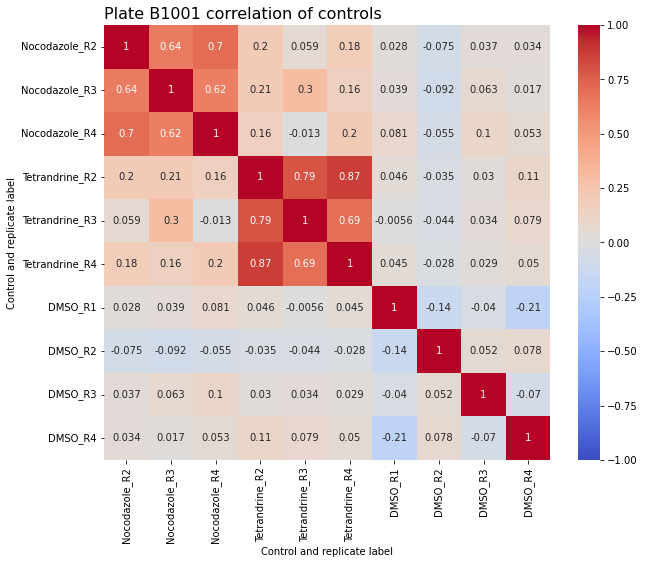

KeyError: 'Metadata_EOS_Replicate'

In [ ]:
plate_list = data_U2OS_reduced_unfiltered["Metadata_Plate"].unique()




for plate in plate_list:

    data_U2OS_reduced_unfiltered_plate = data_U2OS_reduced_unfiltered[data_U2OS_reduced_unfiltered["Metadata_Plate"] == plate]

    features = UTIL.get_feature_vector(data_U2OS_reduced_unfiltered_plate_name)

    data_U2OS_reduced_unfiltered_plate_filtered = data_U2OS_reduced_unfiltered_plate[data_U2OS_reduced_unfiltered_plate['Metadata_EOS'].isin(['Nocodazole', 'Tetrandrine', 'DMSO'])]

    data_U2OS_grouped = data_U2OS_reduced_unfiltered_plate_filtered.groupby(['Metadata_EOS', 'Metadata_Batch'])[features].median().reset_index()

    data_U2OS_grouped["Metadata_EOS_Replicate"] = data_U2OS_grouped["Metadata_EOS"] + "_" + data_U2OS_grouped["Metadata_Batch"]

    custom_order = ['Nocodazole', 'Tetrandrine', 'DMSO']

    df_ordered = data_U2OS_grouped[data_U2OS_grouped['Metadata_EOS'].isin(custom_order)].sort_values('Metadata_EOS', key=lambda x: x.map({name: idx for idx, name in enumerate(custom_order)}))

    df_ordered = df_ordered.set_index("Metadata_EOS_Replicate")

    corr_matrix_all = df_ordered[features].T.corr()

    plt.figure(figsize=(10, 8))

    sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

    plt.xlabel('Control and replicate label')
    plt.ylabel('Control and replicate label')

    # Display the plot
    plt.title(f'Plate {plate} correlation of controls', loc = 'left',fontsize= 16)
    plt.show()

    # plt.savefig(figure_path + os.sep + str(plate) + '_FMP_U2OS_IntraBatchCorr.pdf', format='pdf', bbox_inches = "tight")

    # TODO: compute summar statistics and collect
    mask = np.triu(np.ones(corr_matrix_all.shape), k=1)

    corr_flat = corr_matrix_all.where(mask == 1).stack()


    

    corr_flat_split = corr_flat["Metadata_EOS_Replicate"].str.split('_', expand=True)

    corr_flat_split.columns = ['Metadata_EOS', 'Replicate']

    corr_flat = pd.concat([corr_flat, corr_flat_split], axis=1)

    # mean_corr = corr_flat.mean()



Metadata_EOS_Replicate  Metadata_EOS_Replicate
Nocodazole_R2           Nocodazole_R3             0.606291
                        Nocodazole_R4             0.738237
                        Tetrandrine_R2            0.122231
                        Tetrandrine_R3            0.090378
                        Tetrandrine_R4            0.050914
                        DMSO_R1                  -0.006960
                        DMSO_R2                   0.010666
                        DMSO_R3                   0.070685
                        DMSO_R4                   0.057693
Nocodazole_R3           Nocodazole_R4             0.598314
                        Tetrandrine_R2            0.238603
                        Tetrandrine_R3            0.455383
                        Tetrandrine_R4            0.220809
                        DMSO_R1                  -0.056306
                        DMSO_R2                   0.025029
                        DMSO_R3                   0.038729
         

In [95]:
corr_flat

Metadata_EOS_Replicate  Metadata_EOS_Replicate
Nocodazole_R2           Nocodazole_R3             0.637499
                        Nocodazole_R4             0.700092
                        Tetrandrine_R2            0.202735
                        Tetrandrine_R3            0.059353
                        Tetrandrine_R4            0.184118
                        DMSO_R1                   0.027973
                        DMSO_R2                  -0.075205
                        DMSO_R3                   0.037054
                        DMSO_R4                   0.034260
Nocodazole_R3           Nocodazole_R4             0.618279
                        Tetrandrine_R2            0.205575
                        Tetrandrine_R3            0.298288
                        Tetrandrine_R4            0.156173
                        DMSO_R1                   0.038651
                        DMSO_R2                  -0.092408
                        DMSO_R3                   0.062552
         